# Regresión Lineal y Regularización

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/03_machine_learning/05_regresion_lineal_y_regularizacion.ipynb)

## Objetivos


- Trasladar los conceptos de aprendizaje supervisado a la predicción de valores continuos (Regresión).
- Comprender e interpretar métricas de error en el contexto físico del problema (RMSE en Megapascales).
- Introducir la **Regularización (Ridge y Lasso)** como mecanismo matemático para controlar la complejidad del modelo y manejar la multicolinealidad.



## Prerrequisitos


- Entendimiento del *Trade-off* Sesgo-Varianza.
- Haber completado: [Clasificación: Modelos Lineales y Basados en Distancias](02_clasificacion_lineal_y_distancias.ipynb).

---



## Configuración del Entorno


In [ ]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
from utils.data import load_dataset
setup_plot_style()

## Introducción Teórica



Hasta ahora, hemos predicho categorías discretas (Sano vs. Enfermo, Adulto vs. Niño). Pero en la ingeniería, a menudo necesitamos predecir valores continuos: ¿Cuál será la temperatura del motor? ¿Cuánta carga soportará esta viga? ¿Cuál será el precio de esta casa?

A esto se le llama **Regresión**.



### La Regresión Lineal Múltiple



El modelo más fundamental es la Regresión Lineal. Asume que la variable objetivo ($y$) es una combinación lineal (una suma ponderada) de las características de entrada ($X$).

$$ \hat{y} = w_0 + w_1x_1 + w_2x_2 + ... + w_nx_n $$

Donde:
- $\hat{y}$ es nuestra predicción.
- $w_0$ es la intersección (el valor base si todo lo demás es cero).
- $w_1, w_2, ...$ son los **pesos** o coeficientes que el modelo debe aprender.

El algoritmo busca los pesos que minimicen el **Error Cuadrático Medio (MSE)**, es decir, la distancia al cuadrado entre la línea que dibuja el modelo y los puntos reales de los datos.

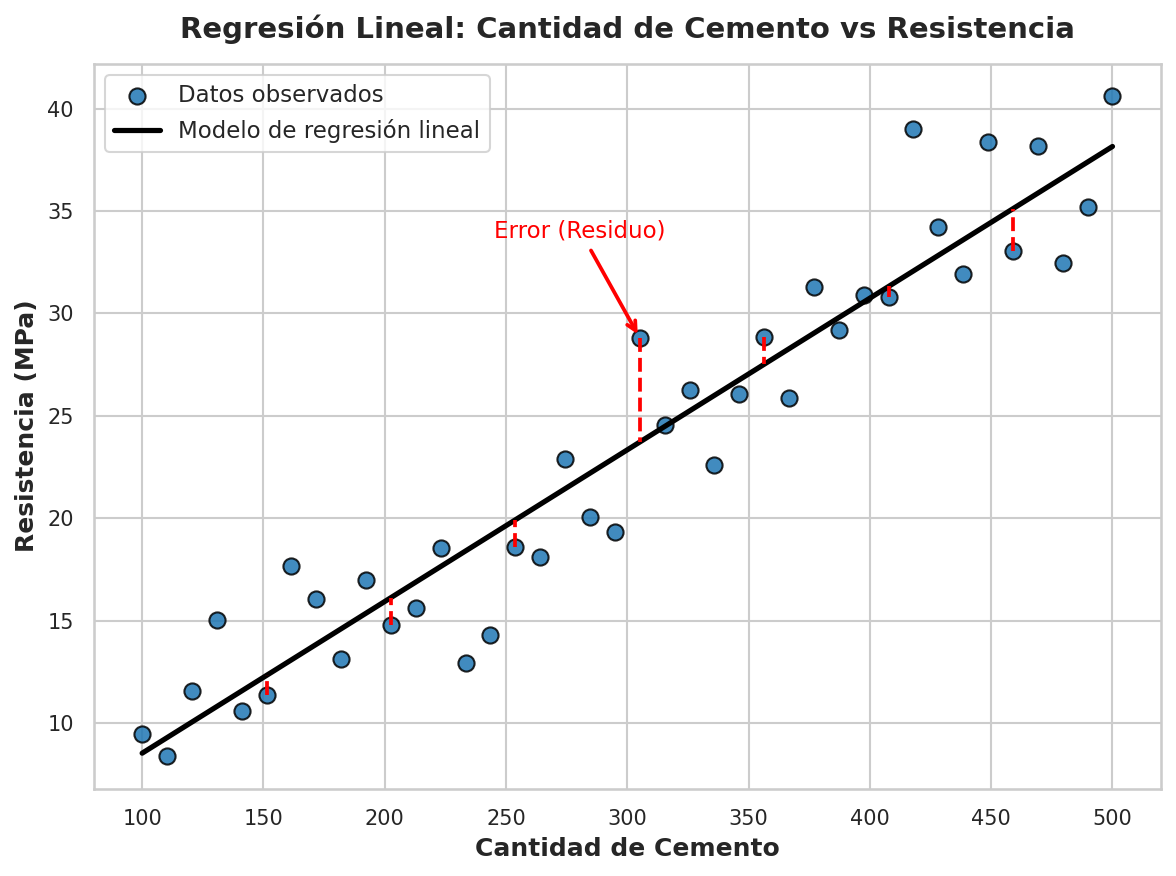

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -----------------------------
# Generación de datos sintéticos
# -----------------------------
np.random.seed(42)

# Cantidad de cemento (variable X)
cemento = np.linspace(100, 500, 40)

# Relación lineal + ruido (Resistencia del concreto) - Inventado por mí, para fines ilustrativos simplemente
resistencia = 0.08 * cemento + np.random.normal(0, 3, size=cemento.shape)

X = cemento.reshape(-1, 1)
y = resistencia

# -----------------------------
# Entrenar modelo de regresión
# -----------------------------
modelo = LinearRegression()
modelo.fit(X, y)

y_pred = modelo.predict(X)

fig, ax = plt.subplots(figsize=(8,6))

# Puntos reales
ax.scatter(
    cemento,
    resistencia,
    color="#1f77b4",
    s=60,
    edgecolor="black",
    alpha=0.85,
    label="Datos observados"
)

# Línea de regresión
ax.plot(
    cemento,
    y_pred,
    color="black",
    linewidth=2.5,
    label="Modelo de regresión lineal"
)

# -----------------------------
# Dibujar residuos
# -----------------------------
indices_residuos = [5, 10, 15, 20, 25, 30, 35]

for i in indices_residuos:
    ax.plot(
        [cemento[i], cemento[i]],
        [resistencia[i], y_pred[i]],
        color="red",
        linestyle="--",
        linewidth=1.8
    )

# Anotar uno como "Error (Residuo)"
i = indices_residuos[3]

ax.annotate(
    "Error (Residuo)",
    xy=(cemento[i], resistencia[i]),
    xytext=(cemento[i]-60, y_pred[i]+10),
    arrowprops=dict(arrowstyle="->", color="red", lw=1.8),
    fontsize=11,
    color="red"
)

# -----------------------------
# Etiquetas y formato
# -----------------------------
ax.set_title(
    "Regresión Lineal: Cantidad de Cemento vs Resistencia",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Cantidad de Cemento", fontsize=12)
ax.set_ylabel("Resistencia (MPa)", fontsize=12)

ax.legend(frameon=True)
ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()

### El Problema de la Multicolinealidad y la Regularización



En un mundo ideal, cada característica ($x$) aporta información única. Pero en la realidad, las variables suelen estar correlacionadas. Por ejemplo, en una mezcla de hormigón, si se aumenta el agua, probablemente se deban ajustar los agregados para mantener el volumen (en un balde entra una cantidad finita de material).

Cuando las variables están altamente correlacionadas (multicolinealidad), las matemáticas de la Regresión Lineal estándar (Mínimos Cuadrados Ordinarios) se vuelven inestables. El modelo puede asignar un peso gigante positivo a una variable y un peso gigante negativo a otra para compensar. Esto genera **Alta Varianza** (*Overfitting*).

**La solución de ingeniería es la Regularización.** Modificamos la función de pérdida para decirle al modelo: *"Minimiza el error, PERO mantén los pesos ($w$) lo más pequeños posible"*.

1. **Ridge (L2):** Penaliza el cuadrado de los pesos ($\alpha \sum w_i^2$). Obliga a los pesos a ser pequeños, distribuyendo la importancia entre variables correlacionadas.
2. **Lasso (L1):** Penaliza el valor absoluto de los pesos ($\alpha \sum |w_i|$). Tiene una propiedad mágica: **fuerza a que algunos pesos sean exactamente cero**, realizando una selección de características automática.



## Desarrollo e Implementación



Vamos a trabajar con el **Concrete Compressive Strength Dataset (CCS)**. Nuestro objetivo es predecir la resistencia a la compresión del hormigón (en Megapascales, MPa) basándonos en sus "ingredientes" y su edad de curado.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Carga de datos
dataset_path = "datasets/ccs/datos_ccs.csv"
df = load_dataset(dataset_path)

# Separamos Features (X) y Target (y)
X = df.drop(columns=['csMPa'])
y = df['csMPa']

# División Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Variables predictoras ({X.shape[1]}): {list(X.columns)}")

Archivo CSV no encontrado. Descomprimiendo /content/applied-ai-engineering/datasets/ccs/datos_ccs.zip...
Descompresión completa. Intentando cargar el CSV.
Dataset cargado exitosamente con 1030 filas y 9 columnas.
Variables predictoras (8): ['cement', 'slag', 'flyash', 'water', 'superplasticizer', 'coarseaggregate', 'fineaggregate', 'age']


### ⚠️ El Requisito Estricto del Escalado



Si vamos a penalizar al modelo por tener "pesos grandes", es **absolutamente obligatorio** que todas las variables estén en la misma escala. Si el Cemento se mide en cientos de kilos y el Superplastificante en gramos, el modelo penalizará injustamente a uno sobre el otro.



In [ ]:
# Escalamos los datos (Ajustamos solo en Train, transformamos Train y Test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Entrenando y Evaluando los Modelos



Vamos a entrenar una Regresión Lineal estándar, un modelo Ridge y un modelo Lasso, y comparamos sus métricas.



In [ ]:
# Instanciamos los modelos
# alpha es el hiperparámetro que controla cuánta penalización aplicamos
modelo_ols = LinearRegression()
modelo_ridge = Ridge(alpha=10.0, random_state=42)
modelo_lasso = Lasso(alpha=1.0, random_state=42)

# Entrenamos
modelo_ols.fit(X_train_scaled, y_train)
modelo_ridge.fit(X_train_scaled, y_train)
modelo_lasso.fit(X_train_scaled, y_train)

# Predecimos
y_pred_ols = modelo_ols.predict(X_test_scaled)
y_pred_ridge = modelo_ridge.predict(X_test_scaled)
y_pred_lasso = modelo_lasso.predict(X_test_scaled)

# Función auxiliar para imprimir métricas
def imprimir_metricas(nombre, y_real, y_pred):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)
    print(f"--- {nombre} ---")
    print(f"RMSE: {rmse:.2f} MPa | MAE: {mae:.2f} MPa | R2: {r2:.3f}\n")

imprimir_metricas("Regresión Lineal (OLS)", y_test, y_pred_ols)
imprimir_metricas("Regresión Ridge (L2)", y_test, y_pred_ridge)
imprimir_metricas("Regresión Lasso (L1)", y_test, y_pred_lasso)

--- Regresión Lineal (OLS) ---
RMSE: 9.80 MPa | MAE: 7.75 MPa | R2: 0.628

--- Regresión Ridge (L2) ---
RMSE: 9.81 MPa | MAE: 7.81 MPa | R2: 0.626

--- Regresión Lasso (L1) ---
RMSE: 10.60 MPa | MAE: 8.72 MPa | R2: 0.564



### Interpretando las Métricas Físicas



A diferencia del *Accuracy* (que es un porcentaje abstracto), las métricas de regresión tienen significado físico:
- **RMSE (Root Mean Squared Error):** Nos dice que, en promedio, nuestras predicciones se desvían de la realidad en unos $\sim 10$ Megapascales. Como penaliza fuertemente los errores grandes, es la métrica preferida en ingeniería.
- **MAE (Mean Absolute Error):** El error absoluto promedio es de $\sim 8.1$ MPa.
- **R2 (Coeficiente de Determinación):** Un valor de $0.62$ indica que nuestro modelo es capaz de explicar el 62% de la varianza (la variabilidad) en la resistencia del hormigón. El 38% restante se debe a factores que no estamos midiendo o a relaciones no lineales.



### Visualizando la Magia de la Regularización



Para entender realmente qué hicieron Ridge y Lasso, vamos a extraer los pesos ($w$) que cada modelo le asignó a cada ingrediente y los graficamos.



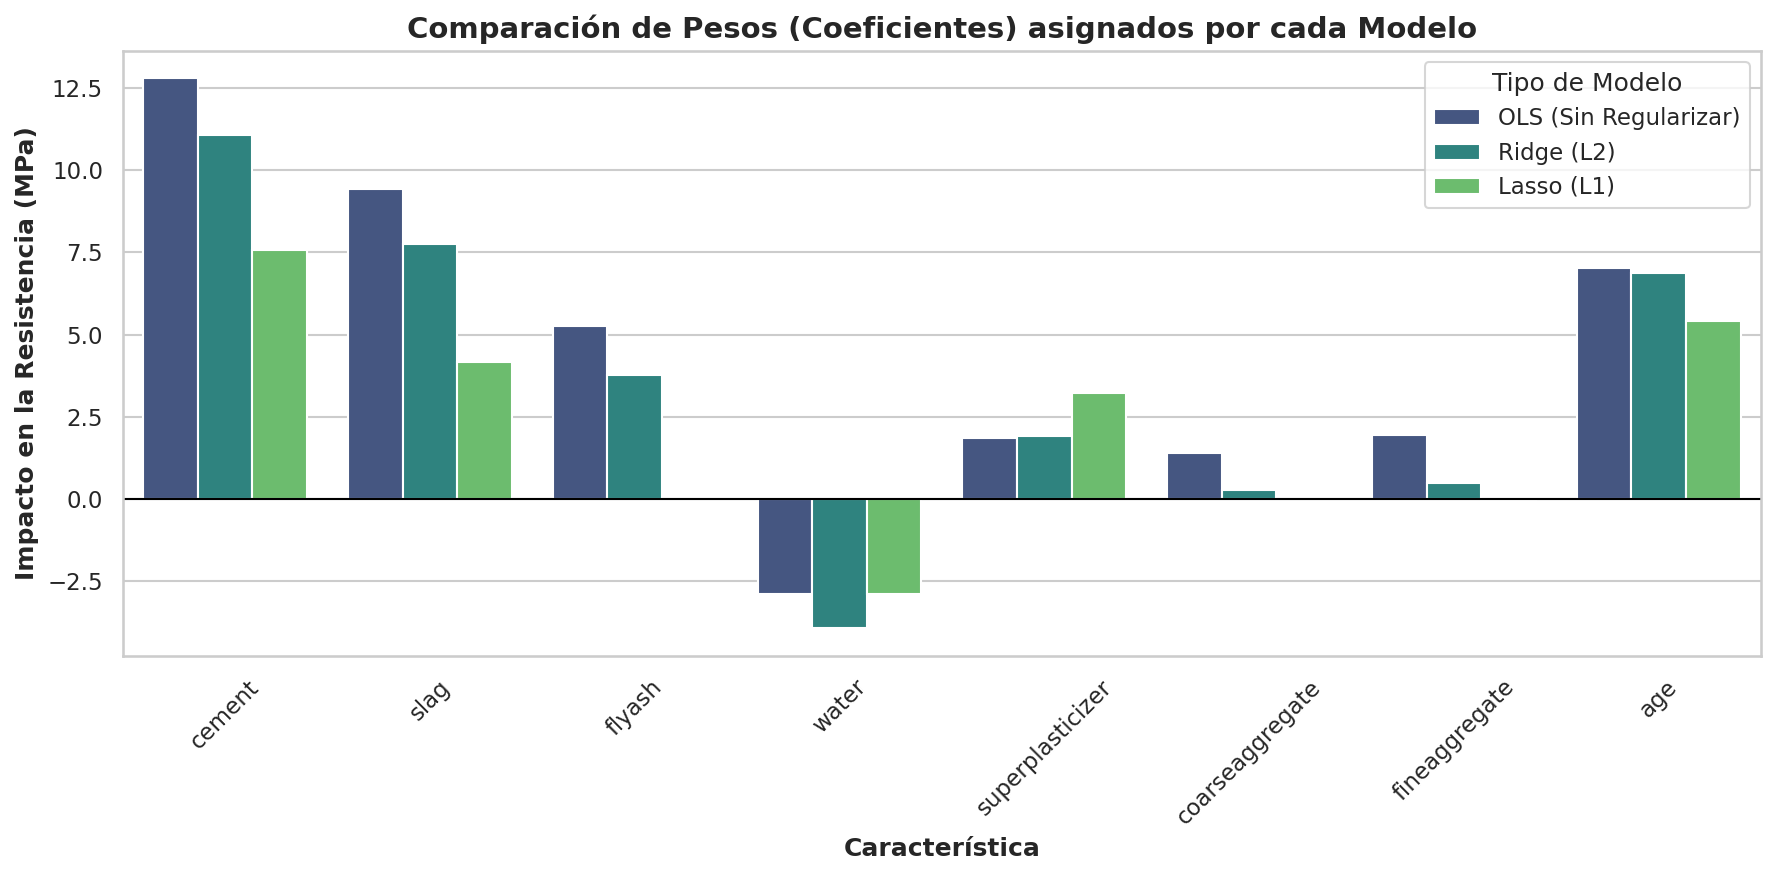

In [19]:
# Extraemos los coeficientes
coeficientes = pd.DataFrame({
    'Característica': X.columns,
    'OLS (Sin Regularizar)': modelo_ols.coef_,
    'Ridge (L2)': modelo_ridge.coef_,
    'Lasso (L1)': modelo_lasso.coef_
})

# "Derretimos" el DataFrame para graficarlo fácilmente con Seaborn
coef_melted = coeficientes.melt(id_vars='Característica', var_name='Modelo', value_name='Peso (Coeficiente)')

import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(data=coef_melted, x='Característica', y='Peso (Coeficiente)', hue='Modelo', palette='viridis')
plt.title("Comparación de Pesos (Coeficientes) asignados por cada Modelo", fontsize=14)
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.ylabel("Impacto en la Resistencia (MPa)")
plt.legend(title="Tipo de Modelo")
plt.tight_layout()
plt.show()

## Resultados y Discusión



Analizar el gráfico de barras con detenimiento. Es una clase magistral de cómo las matemáticas se traducen en física:

1. **Interpretación Física:** Todos los modelos coinciden en que el **Cemento** y la **Edad** (tiempo de curado) tienen un impacto positivo masivo en la resistencia (barras hacia arriba). Por el contrario, el **Agua** tiene un impacto negativo severo (barras hacia abajo). Esto coincide perfectamente con la teoría de la ingeniería civil (la relación agua/cemento).
2. **El Efecto Ridge:** Observar cómo las barras de Ridge (verde oscuro) son generalmente un poco más pequeñas (más cercanas a cero) que las de OLS (azules). Ridge ha "suavizado" los pesos para hacer el modelo más robusto frente a variaciones en los datos.
3. **El Efecto Lasso (Selección de Variables):** Mirar las barras en verde claro. Lasso ha reducido el peso del *Coarse Aggregate* (Agregado Grueso) y del *Fine Aggregate* (Agregado Fino) **exactamente a cero**. Lasso determinó que, matemáticamente, la información que aportan esos agregados ya está contenida en las proporciones de los demás ingredientes, y decidió eliminarlos del modelo para simplificarlo.

## Conexiones y Próximos Pasos


Logramos predecir la resistencia del hormigón con un error de $\sim 10$ MPa usando líneas rectas. Pero, ¿es la relación entre el tiempo de curado (Edad) y la resistencia realmente una línea recta infinita? Sabemos por la física que el hormigón no gana resistencia infinitamente; se estabiliza con el tiempo (una curva logarítmica).

- ➡️ **Siguiente:** En el notebook de [Regresión No Lineal y Extrapolación](06_regresion_no_lineal_y_extrapolacion.ipynb), aplicaremos Árboles y SVM al problema continuo. Descubriremos cómo capturar estas curvas naturales, pero también expondremos el peligro más grande de los modelos no lineales: su incapacidad para extrapolar hacia el futuro.
- 🔄 **Relacionado:** El valor de `alpha` que usamos aquí fue elegido arbitrariamente. Para encontrar el nivel de penalización perfecto, es necesario utilizar técnicas de búsqueda, las vemos en el notebook [Optimización de Hiperparámetros](07_optimizacion_hiperparametros_y_cv.ipynb).



## Referencias


1. Yeh, I.-C. (1998). *Modeling of strength of high-performance concrete using artificial neural networks*. Cement and Concrete Research, 28(12), 1797-1808.
2. [Scikit-Learn: Linear Models and Regularization](https://scikit-learn.org/stable/modules/linear_model.html)

---


## Entorno de Ejecución


In [ ]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.12
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
